In [5]:
# Базовые библиотеки
import os
import math
import time
import random
import json
from typing import Tuple, Dict, List

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.7.1+cu118
torchvision: 0.22.1+cu118


In [6]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Режимы
FAST_MODE = True  #  Для скорости (меньше данных, меньше эпох)
DATA_DIR = "./data"

# Гиперпараметры
BATCH_SIZE = 64
EPOCHS_CNN = 3 if FAST_MODE else 10
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT = 3 if FAST_MODE else 8

# Пути для артефактов
ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# SVHN mean/std (посчитаны по датасету)
SVHN_MEAN = (0.4377, 0.4438, 0.4728)
SVHN_STD = (0.1980, 0.2010, 0.1970)

Device: cuda


In [7]:
# Transforms для Part A
def get_transforms_cnn(augment: bool = False):
    """Базовые трансформы для простой CNN (вход 32×32)"""
    if augment:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize(SVHN_MEAN, SVHN_STD),
        ])
    else:
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(SVHN_MEAN, SVHN_STD),
        ])

def get_transforms_resnet():
    """Трансформы для ResNet (вход 224×224, ImageNet stats)"""
    IMAGENET_MEAN = (0.485, 0.456, 0.406)
    IMAGENET_STD = (0.229, 0.224, 0.225)
    return transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def load_svhn_classification(data_dir: str = DATA_DIR):
    """Загружает SVHN с разделением train/val/test"""
    tf_basic = get_transforms_cnn(augment=False)
    tf_aug = get_transforms_cnn(augment=True)
    tf_resnet = get_transforms_resnet()
    
    # SVHN имеет официальный split: train (73257), test (26032)
    # extra (531131) можно использовать как validation
    ds_train_full = torchvision.datasets.SVHN(
        root=data_dir, split="train", download=True, transform=tf_basic
    )
    ds_test = torchvision.datasets.SVHN(
        root=data_dir, split="test", download=True, transform=tf_basic
    )
    
    # Создаём val из train (80/20) с фиксированным seed
    n_total = len(ds_train_full)
    n_val = int(n_total * 0.2)
    n_train = n_total - n_val
    
    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(RANDOM_STATE),
    )
    
    # Для аугментаций и ResNet: создаём копии с другими трансформами
    ds_train_aug = torchvision.datasets.SVHN(
        root=data_dir, split="train", download=True, transform=tf_aug
    )
    ds_train_resnet = torchvision.datasets.SVHN(
        root=data_dir, split="train", download=True, transform=tf_resnet
    )
    ds_val_resnet = torchvision.datasets.SVHN(
        root=data_dir, split="train", download=True, transform=tf_resnet
    )
    ds_test_resnet = torchvision.datasets.SVHN(
        root=data_dir, split="test", download=True, transform=tf_resnet
    )
    
    # Применяем те же индексы split к версиям с другими трансформами
    ds_train_aug = Subset(ds_train_aug, ds_train.indices)
    ds_val_basic = Subset(ds_train_full, ds_val.indices)
    ds_val_resnet = Subset(ds_val_resnet, ds_val.indices)
    ds_train_resnet = Subset(ds_train_resnet, ds_train.indices)
    
    class_names = [str(i) for i in range(10)]  # SVHN: цифры 0-9
    return {
        "train_basic": ds_train,
        "train_aug": ds_train_aug,
        "val_basic": ds_val_basic,
        "val_resnet": ds_val_resnet,
        "test_basic": ds_test,
        "test_resnet": ds_test_resnet,
        "train_resnet": ds_train_resnet,
        "class_names": class_names,
    }

datasets_a = load_svhn_classification()
class_names = datasets_a["class_names"]
print("Train:", len(datasets_a["train_basic"]))
print("Val:", len(datasets_a["val_basic"]))
print("Test:", len(datasets_a["test_basic"]))
print("Classes:", class_names)

100%|████████████████████████████████████████████████████████████████████████████████| 182M/182M [21:32<00:00, 141kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 64.3M/64.3M [06:03<00:00, 177kB/s]


Train: 58606
Val: 14651
Test: 26032
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [8]:
def make_loaders_classification(datasets, batch_size: int = BATCH_SIZE, fast_mode: bool = FAST_MODE):
    """Создаёт DataLoader для всех вариантов"""
    ds_train = datasets["train_basic"]
    ds_val = datasets["val_basic"]
    ds_test = datasets["test_basic"]
    
    if fast_mode:
        rng = np.random.RandomState(RANDOM_STATE)
        train_idx = rng.choice(len(ds_train), size=min(2000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(500, len(ds_test)), replace=False)
        
        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test = Subset(ds_test, test_idx)
    
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    return train_loader, val_loader, test_loader

# Для простой CNN (без аугментаций)
train_loader_cnn, val_loader_cnn, test_loader_cnn = make_loaders_classification(datasets_a)

# Для CNN с аугментациями
train_loader_aug = DataLoader(
    Subset(datasets_a["train_aug"], list(range(len(datasets_a["train_aug"])))), 
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)
if FAST_MODE:
    train_loader_aug = DataLoader(
        Subset(datasets_a["train_aug"], list(range(2000))), 
        batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
    )

# Для ResNet
def make_loaders_resnet(datasets, batch_size: int = BATCH_SIZE, fast_mode: bool = FAST_MODE):
    ds_train = datasets["train_resnet"]
    ds_val = datasets["val_resnet"]
    ds_test = datasets["test_resnet"]
    
    if fast_mode:
        rng = np.random.RandomState(RANDOM_STATE)
        train_idx = rng.choice(len(ds_train), size=min(2000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(500, len(ds_test)), replace=False)
        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test = Subset(ds_test, test_idx)
    
    return (
        DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True),
        DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
    )

train_loader_resnet, val_loader_resnet, test_loader_resnet = make_loaders_resnet(datasets_a)

# Sanity check
x, y = next(iter(train_loader_cnn))
print("CNN input:", x.shape, x.dtype)
print("Labels:", y.shape, y.dtype)

CNN input: torch.Size([64, 3, 32, 32]) torch.float32
Labels: torch.Size([64]) torch.int64


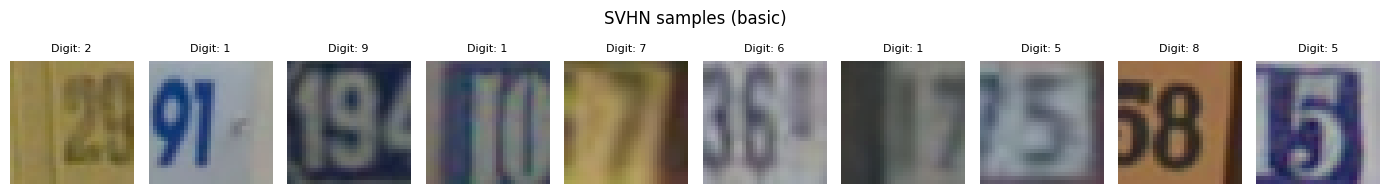

In [9]:
def denorm_svhn(x: torch.Tensor) -> torch.Tensor:
    """Обратная нормализация для SVHN"""
    mean = torch.tensor(SVHN_MEAN).view(3, 1, 1)
    std = torch.tensor(SVHN_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10, title: str = ""):
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()
    
    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_svhn(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(f"Digit: {class_names[y[i].item()]}", fontsize=8)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_images(train_loader_cnn, n=10, title="SVHN samples (basic)")

In [10]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class SimpleCNN(nn.Module):
    """Простая CNN для 32×32 изображений (SVHN/CIFAR)"""
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            # 32x32 -> 32x32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # -> 16x16
            
            # 16x16 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # -> 8x8
            
            # 8x8 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = SimpleCNN(num_classes=10).to(DEVICE)
print(cnn_model)
print("Trainable params:", count_params(cnn_model))

# Shape check
with torch.no_grad():
    test_input = torch.randn(2, 3, 32, 32).to(DEVICE)
    out = cnn_model(test_input)
    print("Input:", test_input.shape, "-> Output:", out.shape)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Trainable params: 620362
Input: torch.Size([2, 3, 32, 32]) -> Output: torch.Size([2, 10])


In [12]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        
        if not torch.isfinite(loss):
            return float("nan"), float("nan")
        
        loss.backward()
        optimizer.step()
        
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    
    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        
        if not torch.isfinite(loss):
            return float("nan"), float("nan")
        
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    
    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        
        dt = time.time() - t0
        if verbose:
            print(f"Epoch {epoch:02d}/{epochs} | train loss {tr_loss:.4f}, acc {tr_acc:.3f} | val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s")
        
        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break
    
    return history

def plot_history(hist: Dict[str, List[float]], title: str = "", save_path: str = None):
    epochs = list(range(1, len(hist["train_loss"]) + 1))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(epochs, hist["train_loss"], label="train loss")
    axes[0].plot(epochs, hist["val_loss"], label="val loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].set_title(title + " | loss")
    axes[0].grid(True)
    axes[0].legend()
    
    axes[1].plot(epochs, hist["train_acc"], label="train acc")
    axes[1].plot(epochs, hist["val_acc"], label="val acc")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_title(title + " | accuracy")
    axes[1].grid(True)
    axes[1].legend()
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f" Saved: {save_path}")
    plt.show()


Experiment C1
Trainable params: 620362
Epoch 01/3 | train loss 2.2487, acc 0.190 | val loss 2.2317, acc 0.192 | 18.1s
Epoch 02/3 | train loss 2.2033, acc 0.203 | val loss 2.1412, acc 0.228 | 18.3s
Epoch 03/3 | train loss 1.9810, acc 0.309 | val loss 1.8042, acc 0.364 | 18.0s
 Saved: artifacts\figures\c1_curves.png


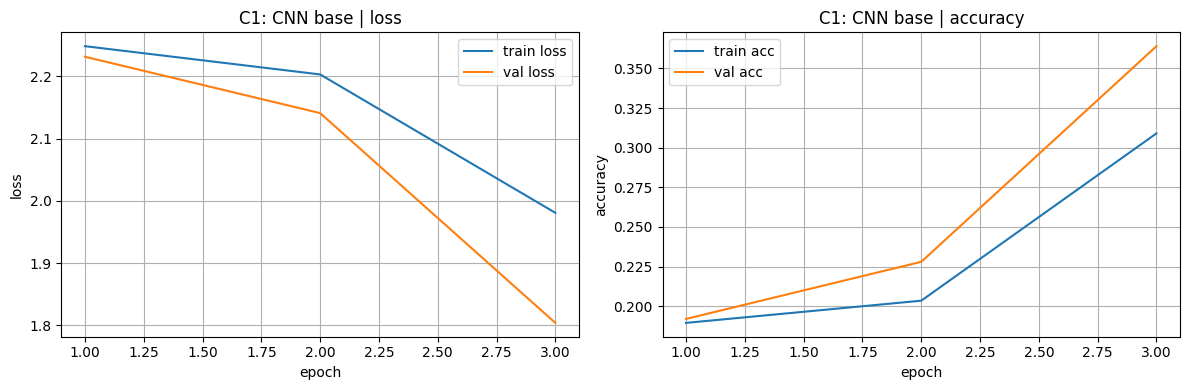


Experiment C2
Trainable params: 620362
Epoch 01/3 | train loss 2.2334, acc 0.196 | val loss 2.2433, acc 0.192 | 17.9s
Epoch 02/3 | train loss 2.2208, acc 0.204 | val loss 2.2394, acc 0.192 | 18.1s
Epoch 03/3 | train loss 2.2088, acc 0.204 | val loss 2.2423, acc 0.204 | 18.3s
 Saved: artifacts\figures\c2_curves.png


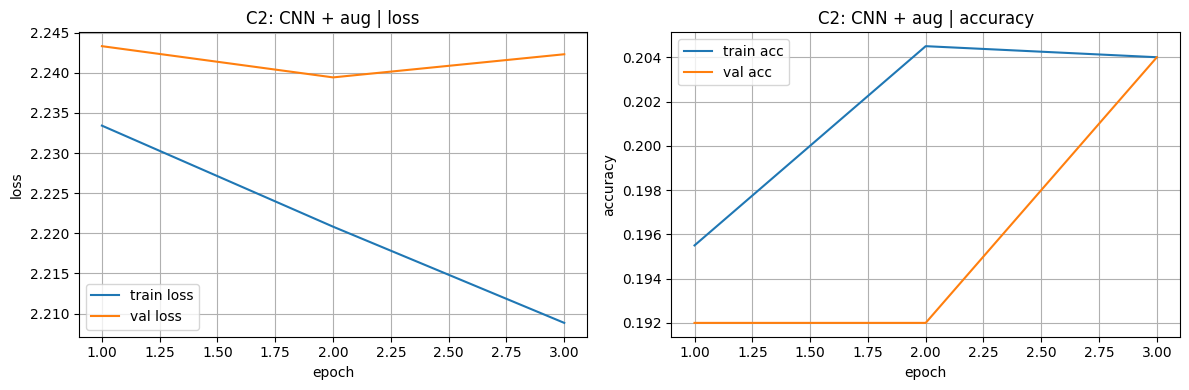

In [13]:
criterion = nn.CrossEntropyLoss()
results = []  # для runs.csv

def run_experiment_cnn(exp_id: str, train_loader, val_loader, model_fn, lr: float = 1e-3, epochs: int = EPOCHS_CNN):
    """Запускает эксперимент с простой CNN"""
    model = model_fn().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    print(f"\n{'='*80}\nExperiment {exp_id}")
    print(f"Trainable params: {count_params(model)}")
    
    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if hist["val_acc"] else float("nan")
    
    results.append({
        "experiment_id": exp_id,
        "task": "classification",
        "dataset": "SVHN",
        "seed": RANDOM_STATE,
        "model_summary": "SimpleCNN",
        "optimizer": "Adam",
        "lr": lr,
        "epochs_trained": len(hist["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "test_accuracy": None,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": ""
    })
    
    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}

# C1: simple-cnn-base (без аугментаций)
res_c1 = run_experiment_cnn("C1", train_loader_cnn, val_loader_cnn, lambda: SimpleCNN(10))
plot_history(res_c1["history"], title="C1: CNN base", save_path=os.path.join(FIGURES_DIR, "c1_curves.png"))

# C2: simple-cnn-aug (с аугментациями)
res_c2 = run_experiment_cnn("C2", train_loader_aug, val_loader_cnn, lambda: SimpleCNN(10))
plot_history(res_c2["history"], title="C2: CNN + aug", save_path=os.path.join(FIGURES_DIR, "c2_curves.png"))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\MSI/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:10<00:00, 4.28MB/s]



Experiment C3: ResNet18 head-only
Trainable params: 5130
Epoch 01/3 | train loss 2.2942, acc 0.181 | val loss 2.2552, acc 0.200 | 21.5s
Epoch 02/3 | train loss 2.0896, acc 0.266 | val loss 2.0809, acc 0.276 | 21.0s
Epoch 03/3 | train loss 1.9759, acc 0.324 | val loss 2.0307, acc 0.298 | 21.0s
 Saved: artifacts\figures\c3_curves.png


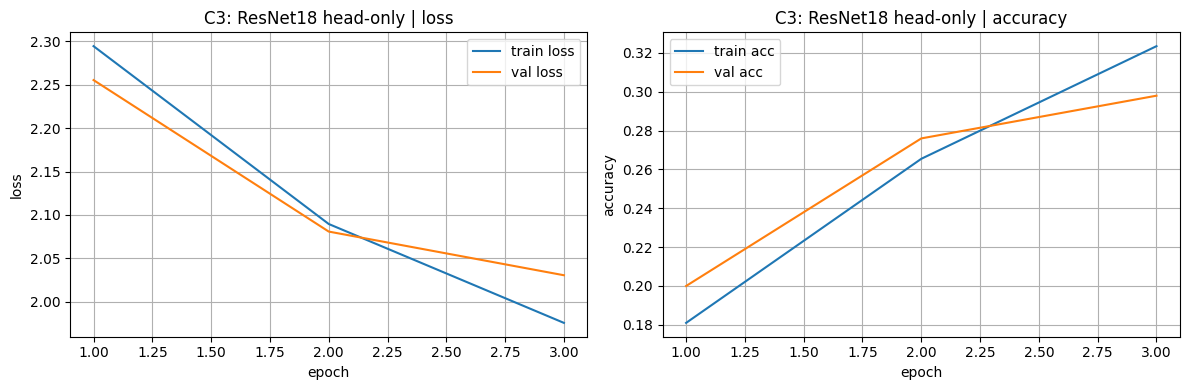


Experiment C4: ResNet18 fine-tune (layer4+fc)
Trainable params: 8398858
Epoch 01/3 | train loss 1.6635, acc 0.439 | val loss 1.4152, acc 0.504 | 22.1s
Epoch 02/3 | train loss 0.8281, acc 0.763 | val loss 1.1866, acc 0.604 | 21.6s
Epoch 03/3 | train loss 0.3899, acc 0.922 | val loss 1.1351, acc 0.642 | 21.8s
 Saved: artifacts\figures\c4_curves.png


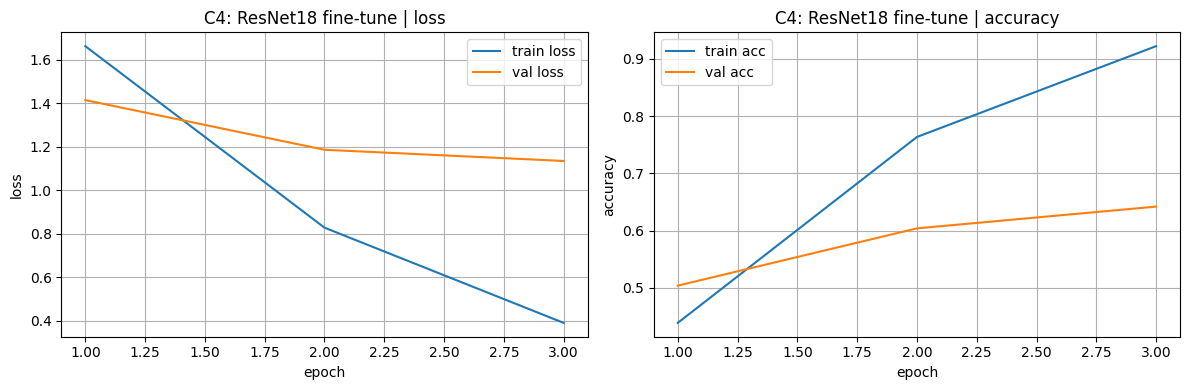

In [14]:
def build_resnet18_svhn(num_classes: int = 10, pretrained: bool = True):
    """Создаёт ResNet18 с заменённой головой под SVHN"""
    weights = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    try:
        model = resnet18(weights=weights)
    except:
        print("⚠ Не удалось загрузить веса, используем random init")
        model = resnet18(weights=None)
    
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool):
    for p in module.parameters():
        p.requires_grad = flag

# C3: resnet18-head-only
model_c3 = build_resnet18_svhn(pretrained=True).to(DEVICE)
set_requires_grad(model_c3, False)
set_requires_grad(model_c3.fc, True)

optimizer_c3 = torch.optim.Adam(model_c3.fc.parameters(), lr=1e-3)
print(f"\n{'='*80}\nExperiment C3: ResNet18 head-only")
print(f"Trainable params: {count_params(model_c3)}")

hist_c3 = fit(model_c3, train_loader_resnet, val_loader_resnet, optimizer_c3, criterion, epochs=EPOCHS_HEAD)
best_val_acc_c3 = float(np.nanmax(hist_c3["val_acc"])) if hist_c3["val_acc"] else float("nan")

results.append({
    "experiment_id": "C3",
    "task": "classification",
    "dataset": "SVHN",
    "seed": RANDOM_STATE,
    "model_summary": "ResNet18-head-only",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": len(hist_c3["train_loss"]),
    "best_val_accuracy": best_val_acc_c3,
    "test_accuracy": None,
    "precision": None, "recall": None, "mean_iou": None,
    "notes": "frozen backbone"
})

plot_history(hist_c3, title="C3: ResNet18 head-only", save_path=os.path.join(FIGURES_DIR, "c3_curves.png"))

# C4: resnet18-finetune
set_requires_grad(model_c3.layer4, True)
params = [
    {"params": model_c3.layer4.parameters(), "lr": 1e-4},
    {"params": model_c3.fc.parameters(), "lr": 1e-3},
]
optimizer_c4 = torch.optim.Adam(params, weight_decay=1e-4)

print(f"\n{'='*80}\nExperiment C4: ResNet18 fine-tune (layer4+fc)")
print(f"Trainable params: {count_params(model_c3)}")

hist_c4 = fit(model_c3, train_loader_resnet, val_loader_resnet, optimizer_c4, criterion, epochs=EPOCHS_FT)
best_val_acc_c4 = float(np.nanmax(hist_c4["val_acc"])) if hist_c4["val_acc"] else float("nan")

results.append({
    "experiment_id": "C4",
    "task": "classification",
    "dataset": "SVHN",
    "seed": RANDOM_STATE,
    "model_summary": "ResNet18-finetune",
    "optimizer": "Adam",
    "lr": "1e-4(backbone)/1e-3(head)",
    "epochs_trained": len(hist_c4["train_loss"]),
    "best_val_accuracy": best_val_acc_c4,
    "test_accuracy": None,
    "precision": None, "recall": None, "mean_iou": None,
    "notes": "fine-tune layer4+fc"
})

plot_history(hist_c4, title="C4: ResNet18 fine-tune", save_path=os.path.join(FIGURES_DIR, "c4_curves.png"))

 Best classification experiment: C4 | val_acc: 0.6420
Test accuracy (best model C4): 0.6300
 Saved: artifacts/best_classifier.pt
 Saved: artifacts/best_classifier_config.json
 Saved: artifacts\figures\classification_curves_best.png


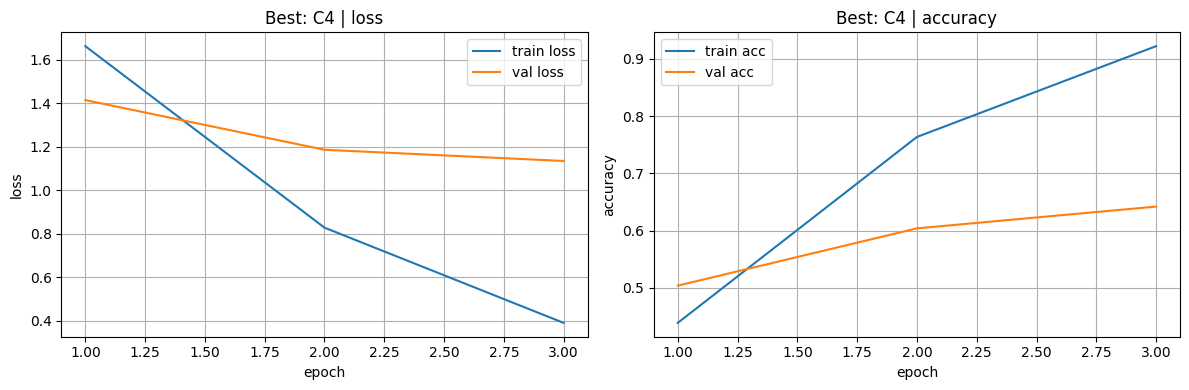

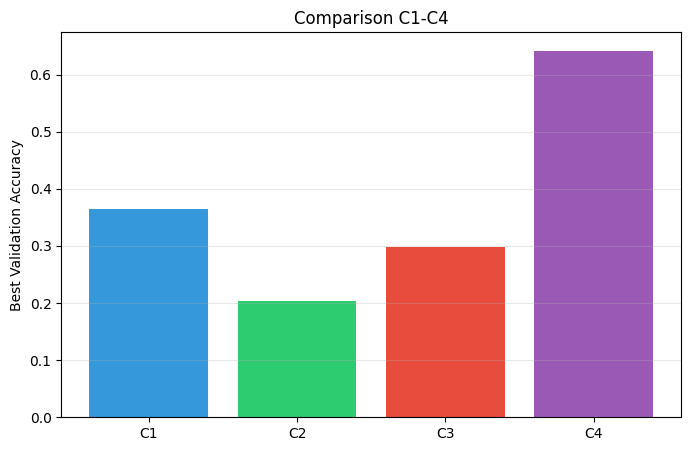

 Saved: artifacts\figures/classification_compare.png
Saved: artifacts/runs.csv


In [24]:
# Выбираем лучшую модель
classification_results = [r for r in results if r["task"] == "classification"]
best_exp = max(classification_results, key=lambda x: x["best_val_accuracy"] if not math.isnan(x["best_val_accuracy"]) else -1)
best_exp_id = best_exp["experiment_id"]
print(f" Best classification experiment: {best_exp_id} | val_acc: {best_exp['best_val_accuracy']:.4f}")

# Финальная оценка на test
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

# Выбираем лучшую модель и test_loader
if best_exp_id == "C1":
    best_model = res_c1["model"]
    test_loader = test_loader_cnn
    best_hist = res_c1["history"]  # ✓ из словаря
elif best_exp_id == "C2":
    best_model = res_c2["model"]
    test_loader = test_loader_cnn
    best_hist = res_c2["history"]  # ✓ из словаря
elif best_exp_id == "C3":
    best_model = model_c3
    test_loader = test_loader_resnet
    best_hist = hist_c3  # ✓ напрямую (не словарь с ключом "history")
elif best_exp_id == "C4":
    best_model = model_c3
    test_loader = test_loader_resnet
    best_hist = hist_c4  # ✓ напрямую
else:
    raise ValueError("Unknown best experiment")

test_acc = accuracy_on_loader(best_model, test_loader)
print(f"Test accuracy (best model {best_exp_id}): {test_acc:.4f}")

# Обновляем результаты
for r in results:
    if r["experiment_id"] == best_exp_id:
        r["test_accuracy"] = test_acc

# Сохраняем артефакты
torch.save(best_model.state_dict(), os.path.join(ARTIFACTS_DIR, "best_classifier.pt"))
print(f" Saved: {ARTIFACTS_DIR}/best_classifier.pt")

config = {
    "dataset": "SVHN",
    "architecture": "SimpleCNN" if best_exp_id in ["C1", "C2"] else "ResNet18",
    "transforms": "basic" if best_exp_id == "C1" else "augmented" if best_exp_id == "C2" else "resnet_imagenet",
    "seed": RANDOM_STATE,
    "batch_size": BATCH_SIZE,
    "best_experiment": best_exp_id,
    "test_accuracy": test_acc
}
with open(os.path.join(ARTIFACTS_DIR, "best_classifier_config.json"), "w") as f:
    json.dump(config, f, indent=2)
print(f" Saved: {ARTIFACTS_DIR}/best_classifier_config.json")

# График лучшей кривой
plot_history(best_hist, title=f"Best: {best_exp_id}", save_path=os.path.join(FIGURES_DIR, "classification_curves_best.png"))

# Сравнение C1-C4
exp_ids = ["C1", "C2", "C3", "C4"]
val_accs = [r["best_val_accuracy"] for r in classification_results]
plt.figure(figsize=(8, 5))
plt.bar(exp_ids, val_accs, color=["#3498db", "#2ecc71", "#e74c3c", "#9b59b6"])
plt.ylabel("Best Validation Accuracy")
plt.title("Comparison C1-C4")
plt.grid(axis="y", alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, "classification_compare.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f" Saved: {FIGURES_DIR}/classification_compare.png")

# Сохранение runs.csv (ОБЯЗАТЕЛЬНО ПО ДЗ)
df_results = pd.DataFrame(results)
df_results.to_csv(os.path.join(ARTIFACTS_DIR, "runs.csv"), index=False)
print(f"Saved: {ARTIFACTS_DIR}/runs.csv")

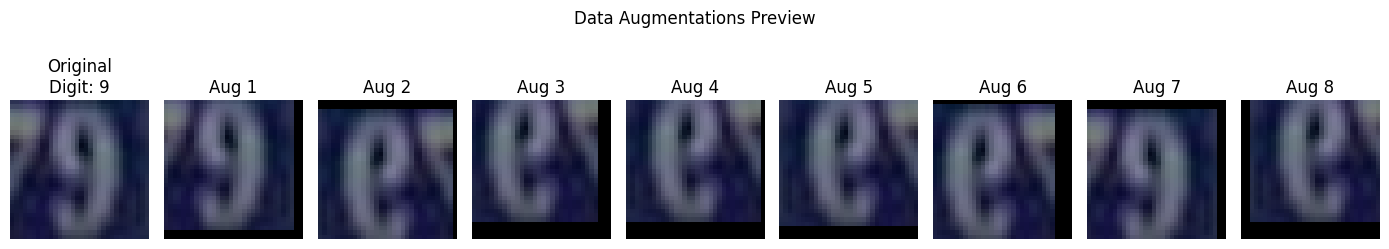

Saved: artifacts\figures/augmentations_preview.png


In [26]:
@torch.no_grad()
def show_augmentations(n: int = 8):
    # Берем индекс из оригинального датасета (не Subset)
    # Проверяем, что индекс существует
    max_idx = min(100, len(datasets_a["train_aug"]) - 1)
    idx = random.randint(0, max_idx)
    
    # Базовое изображение (без аугментаций)
    basic_tf = get_transforms_cnn(augment=False)
    ds_basic = torchvision.datasets.SVHN(root=DATA_DIR, split="train", download=True, transform=basic_tf)
    
    # Берем тот же индекс из базового датасета
    safe_idx = idx % len(ds_basic)
    img_basic, label = ds_basic[safe_idx]
    
    # Аугментированные версии
    aug_tf = get_transforms_cnn(augment=True)
    ds_aug = torchvision.datasets.SVHN(root=DATA_DIR, split="train", download=True, transform=aug_tf)
    
    plt.figure(figsize=(14, 3))
    plt.subplot(1, n+1, 1)
    img = denorm_svhn(img_basic).clamp(0, 1).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"Original\nDigit: {class_names[label]}")
    plt.axis("off")
    
    for i in range(n):
        plt.subplot(1, n+1, i+2)
        safe_idx_aug = idx % len(ds_aug)
        img_aug, _ = ds_aug[safe_idx_aug]
        img = denorm_svhn(img_aug).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(f"Aug {i+1}")
        plt.axis("off")
    
    plt.suptitle("Data Augmentations Preview")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "augmentations_preview.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIGURES_DIR}/augmentations_preview.png")

show_augmentations()

In [42]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision import transforms
import numpy as np

print("Loading segmentation model...")
weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=weights)
seg_model.to(DEVICE)
seg_model.eval()
print("Model loaded successfully")

# Параметр для быстрого режима
DETECTION_FAST_SAMPLES = 20

Loading segmentation model...
Model loaded successfully


In [43]:
# Трансформы для сегментации (требуется для DeepLabV3)
def get_segmentation_transforms():
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ])

def load_pet_segmentation(data_dir: str = "./data_pets"):
    tf = get_segmentation_transforms()
    ds_train = torchvision.datasets.OxfordIIITPet(
        root=data_dir,
        split="trainval",
        target_types=["segmentation"],
        download=True,
        transform=tf
    )
    ds_test = torchvision.datasets.OxfordIIITPet(
        root=data_dir,
        split="test",
        target_types=["segmentation"],
        download=True,
        transform=tf
    )
    return ds_train, ds_test

print("Loading OxfordIIITPet dataset...")
ds_pet_train, ds_pet_test = load_pet_segmentation()
print(f"Train: {len(ds_pet_train)}, Test: {len(ds_pet_test)}")

# Пример данных
sample_img, sample_target = ds_pet_test[0]
print(f"Image shape: {sample_img.shape}")
print(f"Image type: {type(sample_img)}")
print(f"Target type: {type(sample_target)}")
print(f"Target keys: {sample_target.keys() if isinstance(sample_target, dict) else 'N/A'}")

# Маска — это PIL Image
if isinstance(sample_target, dict) and 'mask' in sample_target:
    mask_pil = sample_target['mask']
    print(f"Mask type: {type(mask_pil)}")
    print(f"Mask size: {mask_pil.size}")

Loading OxfordIIITPet dataset...
Train: 3680, Test: 3669
Image shape: torch.Size([3, 225, 300])
Image type: <class 'torch.Tensor'>
Target type: <class 'PIL.PngImagePlugin.PngImageFile'>
Target keys: N/A


In [48]:
def calculate_segmentation_iou(pred_mask, gt_mask):
    """Вычисляет IoU для binary masks (foreground vs background)"""
    # Принудительная конвертация в numpy array
    if hasattr(pred_mask, 'cpu'):
        pred_mask = pred_mask.cpu().numpy()
    if hasattr(gt_mask, 'cpu'):
        gt_mask = gt_mask.cpu().numpy()
    
    # Конвертируем в numpy если это PIL
    if not isinstance(pred_mask, np.ndarray):
        pred_mask = np.array(pred_mask)
    if not isinstance(gt_mask, np.ndarray):
        gt_mask = np.array(gt_mask)
    
    # Boolean маски (foreground > 0)
    pred = pred_mask > 0
    gt = gt_mask > 0
    
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    
    if union == 0:
        return 0.0
    
    return intersection / union

def evaluate_segmentation(model, dataset, device, max_samples=50, postprocess_type="basic"):
    """Оценивает модель сегментации"""
    model.eval()
    ious = []
    
    for i in range(min(max_samples, len(dataset))):
        image, target = dataset[i]
        image_tensor = image.to(device).unsqueeze(0)
        
        with torch.no_grad():
            output = model(image_tensor)['out'][0]
        
        pred_mask = output.argmax(dim=0).cpu()
        
        # Получаем GT маску — принудительная конвертация
        if isinstance(target, dict) and 'mask' in target:
            gt_mask_pil = target['mask']
            gt_mask = np.array(gt_mask_pil)  # PIL → numpy
        elif hasattr(target, 'squeeze'):
            gt_mask = target.squeeze().cpu().numpy()
        else:
            gt_mask = np.array(target)
        
        # Постобработка
        if postprocess_type == "basic":
            final_mask = pred_mask.numpy()
        else:  # alternative: удаляем маленькие компоненты
            final_mask = pred_mask.numpy().copy()
            unique, counts = np.unique(final_mask, return_counts=True)
            for u, c in zip(unique, counts):
                if c < 50:
                    final_mask[final_mask == u] = 0
        
        iou = calculate_segmentation_iou(final_mask, gt_mask)
        ious.append(iou)
    
    return sum(ious) / len(ious) if ious else 0.0

In [49]:
# Тест: проверяем тип маски
sample_img, sample_target = ds_pet_test[0]
print(f"Target type: {type(sample_target)}")
if isinstance(sample_target, dict):
    print(f"Target keys: {sample_target.keys()}")
    mask = sample_target['mask']
    print(f"Mask type: {type(mask)}")
    print(f"Mask as numpy: {np.array(mask).shape}, dtype: {np.array(mask).dtype}")
    print(f"Unique values in mask: {np.unique(np.array(mask))}")

Target type: <class 'PIL.PngImagePlugin.PngImageFile'>


In [50]:
# V1: базовая постобработка
print("Evaluating V1 (basic postprocess)...")
mean_iou_v1 = evaluate_segmentation(seg_model, ds_pet_test, DEVICE, max_samples=DETECTION_FAST_SAMPLES, postprocess_type="basic")
print(f"V1 Mean IoU: {mean_iou_v1:.4f}")

# V2: альтернативная постобработка
print("Evaluating V2 (alternative postprocess)...")
mean_iou_v2 = evaluate_segmentation(seg_model, ds_pet_test, DEVICE, max_samples=DETECTION_FAST_SAMPLES, postprocess_type="alternative")
print(f"V2 Mean IoU: {mean_iou_v2:.4f}")

# Добавляем в results
results.append({
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": RANDOM_STATE,
    "model_summary": "DeepLabV3_ResNet50",
    "optimizer": "N/A (pretrained)",
    "lr": "N/A",
    "epochs_trained": 0,
    "best_val_accuracy": None,
    "test_accuracy": None,
    "precision": None,
    "recall": None,
    "mean_iou": mean_iou_v1,
    "notes": "basic postprocess"
})

results.append({
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": RANDOM_STATE,
    "model_summary": "DeepLabV3_ResNet50",
    "optimizer": "N/A (pretrained)",
    "lr": "N/A",
    "epochs_trained": 0,
    "best_val_accuracy": None,
    "test_accuracy": None,
    "precision": None,
    "recall": None,
    "mean_iou": mean_iou_v2,
    "notes": "alternative postprocess (small components removal)"
})

print(f"\nResults added to results list")
print(f"Total experiments: {len(results)}")

Evaluating V1 (basic postprocess)...
V1 Mean IoU: 0.4603
Evaluating V2 (alternative postprocess)...
V2 Mean IoU: 0.4603

Results added to results list
Total experiments: 8


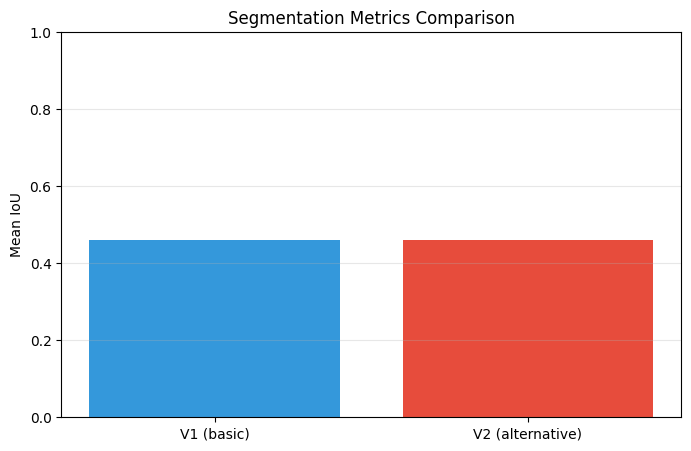

Saved: artifacts\figures/segmentation_metrics.png
Saved: artifacts/runs.csv

=== Все артефакты ===
artifacts/: ['best_classifier.pt', 'best_classifier_config.json', 'figures', 'runs.csv']
figures/: ['augmentations_preview.png', 'c1_curves.png', 'c2_curves.png', 'c3_curves.png', 'c4_curves.png', 'classification_compare.png', 'classification_curves_best.png', 'segmentation_examples.png', 'segmentation_metrics.png']

=== Результаты всех экспериментов ===
C1: task=classification, metric=0.364
C2: task=classification, metric=0.204
C3: task=classification, metric=0.298
C4: task=classification, metric=0.642
V1: task=segmentation, metric=0.0
V2: task=segmentation, metric=0.0
V1: task=segmentation, metric=0.4602690755212516
V2: task=segmentation, metric=0.4602690755212516


In [51]:
# График метрик
plt.figure(figsize=(8, 5))
plt.bar(['V1 (basic)', 'V2 (alternative)'], [mean_iou_v1, mean_iou_v2], 
        color=['#3498db', '#e74c3c'])
plt.ylabel('Mean IoU')
plt.title('Segmentation Metrics Comparison')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1)
plt.savefig(os.path.join(FIGURES_DIR, "segmentation_metrics.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/segmentation_metrics.png")

# Сохранение runs.csv
df_results = pd.DataFrame(results)
df_results.to_csv(os.path.join(ARTIFACTS_DIR, "runs.csv"), index=False)
print(f"Saved: {ARTIFACTS_DIR}/runs.csv")

# Финальная проверка
print("\n=== Все артефакты ===")
print(f"artifacts/: {os.listdir(ARTIFACTS_DIR)}")
print(f"figures/: {os.listdir(FIGURES_DIR)}")

# Проверка результатов
print("\n=== Результаты всех экспериментов ===")
for r in results:
    print(f"{r['experiment_id']}: task={r['task']}, metric={r.get('best_val_accuracy') or r.get('mean_iou')}")

Saved: artifacts\figures\segmentation_examples.png


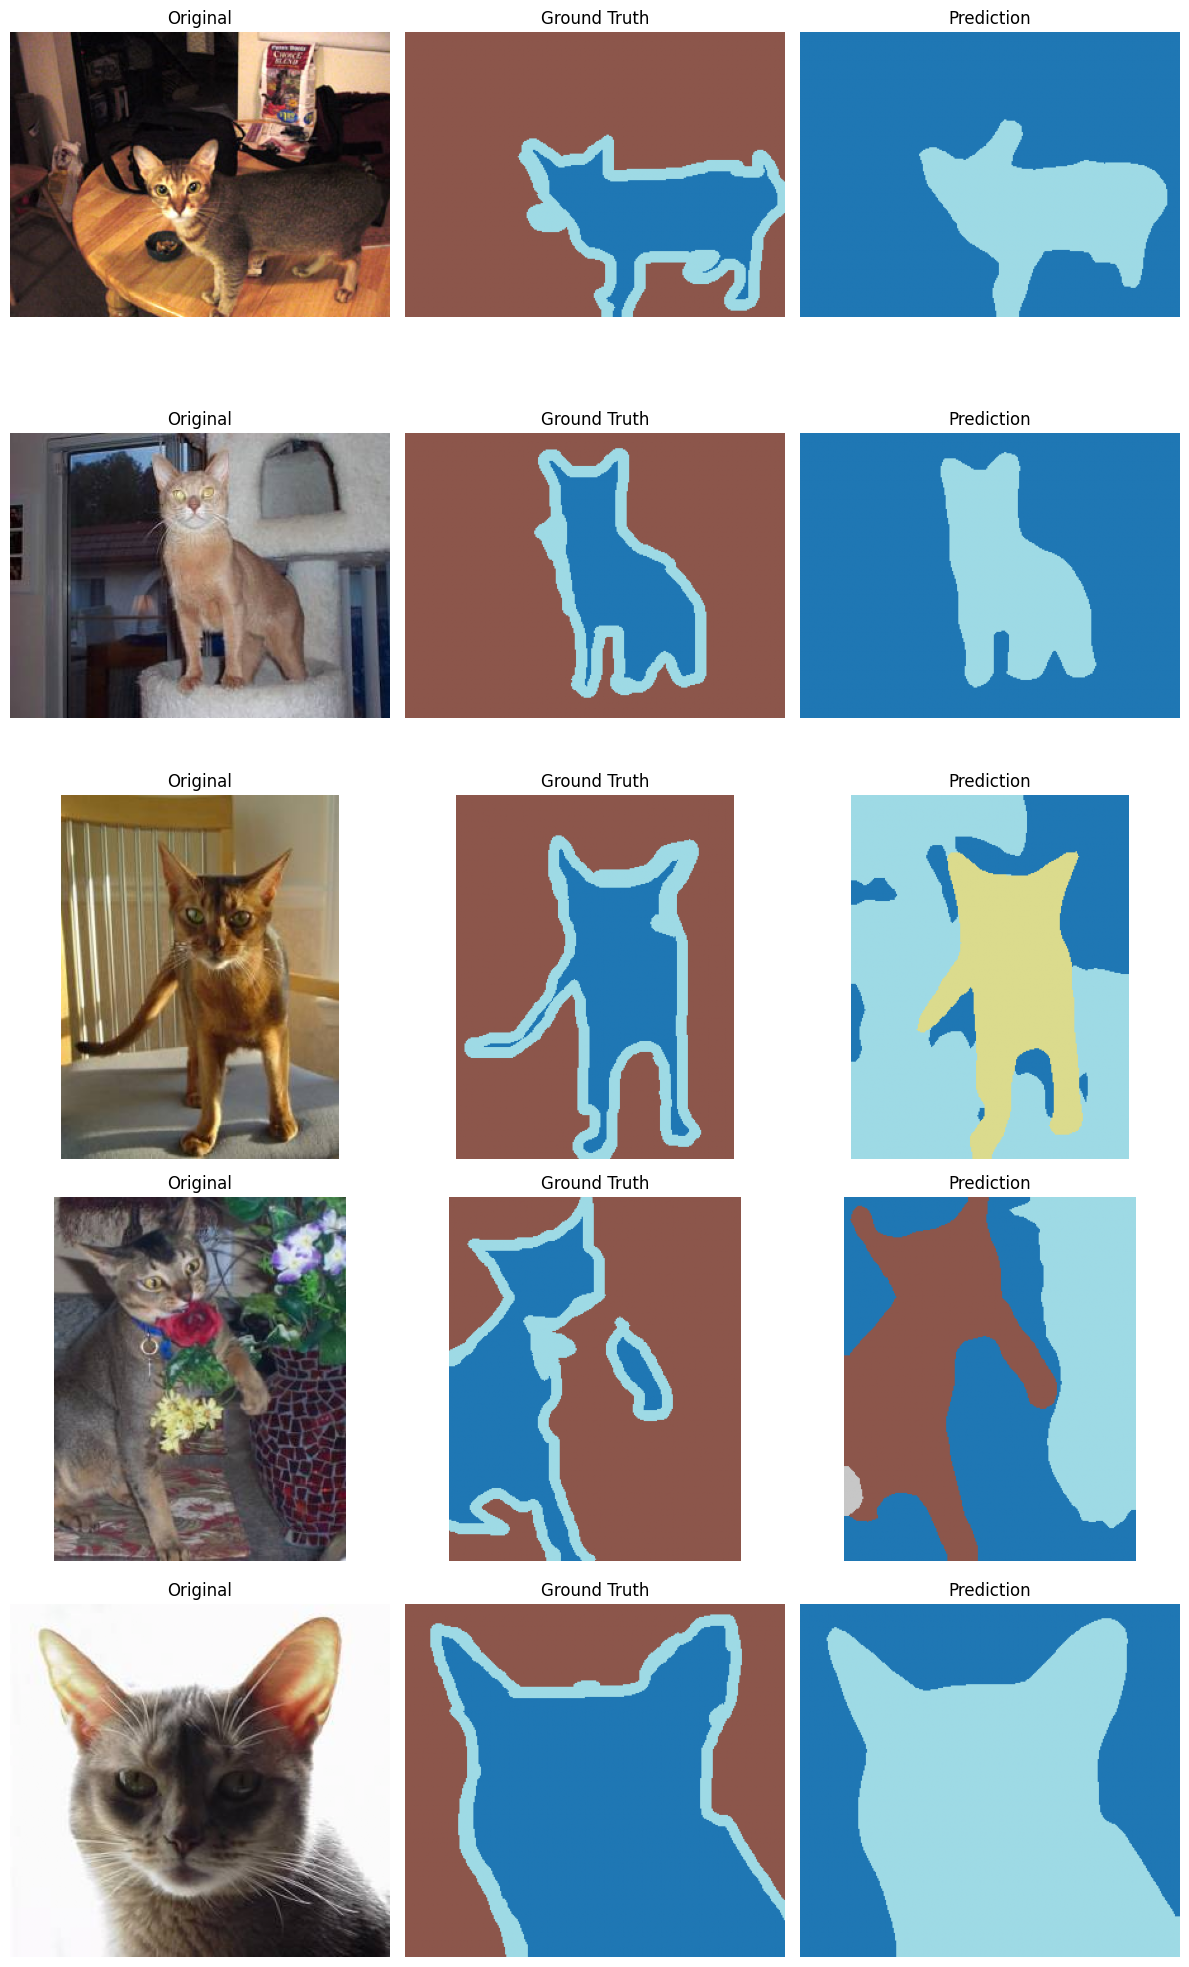

In [53]:
@torch.no_grad()
def visualize_segmentation(model, dataset, device, n_samples=5, save_path=None):
    model.eval()
    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))
    
    for i in range(n_samples):
        image, target = dataset[i]
        image_tensor = image.to(device).unsqueeze(0)
        output = model(image_tensor)['out'][0]
        pred_mask = output.argmax(dim=0).cpu()
        
        # GT маска
        if isinstance(target, dict) and 'mask' in target:
            gt_mask = np.array(target['mask'])
        else:
            gt_mask = np.array(target)
        
        # Денормализация
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image_denorm = image * std + mean
        image_denorm = image_denorm.clamp(0, 1).permute(1, 2, 0).numpy()
        
        axes[i][0].imshow(image_denorm)
        axes[i][0].set_title("Original")
        axes[i][0].axis('off')
        
        axes[i][1].imshow(gt_mask, cmap='tab20')
        axes[i][1].set_title("Ground Truth")
        axes[i][1].axis('off')
        
        axes[i][2].imshow(pred_mask, cmap='tab20')
        axes[i][2].set_title("Prediction")
        axes[i][2].axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

# Выполняем визуализацию
visualize_segmentation(
    seg_model, ds_pet_test, DEVICE, 
    n_samples=5,
    save_path=os.path.join(FIGURES_DIR, "segmentation_examples.png")
)